In [3]:
import pandas as pd
import sys
import numpy as np
from matplotlib import pyplot as plt
from pandas import DataFrame
from matplotlib.colors import BoundaryNorm

In [4]:
DATABASE_GOOD = "sqlite:///../data/track2_good.db"
DATABASE_BAD = "sqlite:///../data/track2_bad.db"
OUTPUT = '../data/output.txt'
PROMPTS = '../prompts/prompts.txt'
START_SEQUENCE = 10
END_SEQUENCE = 25
TRACK_2_SEGMENT_POINTS = [(923, 2590), (610, 2485), (635, 2780), (525, 2720), (880, 2790)]

In [5]:
def preprocess(df):
    df['timestamp'] = pd.to_datetime(df["timestamp"], utc=True).astype("int64") // 10**6
    df['timestamp'] = (df['timestamp'] - min(df['timestamp'])) / 1000

    df['position_x'] = df['position_x'].astype(int)
    df['position_y'] = df['position_y'].astype(int)
    df['position_z'] = df['position_z'].astype(int)

    df['acceleration_x'] = df['acceleration_x'].astype(int)
    df['acceleration_y'] = df['acceleration_y'].astype(int)
    df['acceleration_z'] = df['acceleration_z'].astype(int)
    df['yaw'] = df['yaw'].round(decimals=2)
    df['speed'] = (df['speed'] * 3.6).astype(int)
    
    return df

# Preprocessing


In [6]:
df_fast = pd.read_sql(
    """
    SELECT 
        timestamp_utc AS timestamp,
        acceleration_x,
        acceleration_y,
        acceleration_z,
        yaw,
        position_x,
        position_y,
        position_z,
        speed, 
        lap_number
    FROM telemetry_samples
    WHERE distance_traveled != 0
    ORDER BY id
    """,
    DATABASE_GOOD
)

df_slow = pd.read_sql(
    """
    SELECT 
        timestamp_utc AS timestamp,
        acceleration_x,
        acceleration_y,
        acceleration_z,
        yaw,
        position_x,
        position_y,
        position_z,
        speed,
        lap_number
    FROM telemetry_samples
    WHERE distance_traveled != 0
    ORDER BY id
    """,
    DATABASE_BAD
)

df_fast = preprocess(df_fast)
df_slow = preprocess(df_slow)

df_slow = df_slow.iloc[::int(19), :]

# Side information
print(df_slow.shape)

(72, 10)


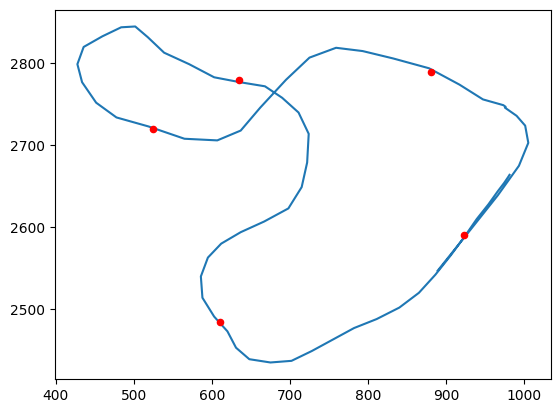

In [7]:
plt.plot(df_slow['position_x'].values, df_slow['position_z'].values)
plt.scatter([i[0] for i in TRACK_2_SEGMENT_POINTS], [i[1] for i in TRACK_2_SEGMENT_POINTS], c='red', s=20, zorder=5)
plt.show()

In [8]:
def get_index_nearest_position(point: tuple, positions_x: np.ndarray, positions_z: np.ndarray) -> int:
    smallest_distance = np.inf

    for i in range(positions_x.shape[0]):
        distance = np.sqrt(((point[0] - positions_x[i])**2 + (point[1] - positions_z[i])**2))
        if distance < smallest_distance:
            smallest_distance = distance
            index = i
    
    return index

def segment_labels(points: list, track: DataFrame):
    labels = []
    segment = 0

    for point in points:
        index = get_index_nearest_position(point, track['position_x'].values, track['position_z'].values)
        labels += [segment] * (index - len(labels))
        segment += 1
    
    
    return labels

df_slow['segment'] = (segment_labels(TRACK_2_SEGMENT_POINTS, df_slow) + [6] * df_slow.shape[0])[:df_slow.shape[0]]

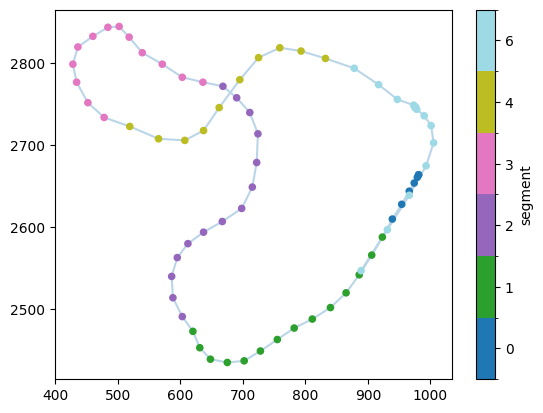

In [9]:
x = df_slow["position_x"].to_numpy()
z = df_slow["position_z"].to_numpy()
seg = df_slow["segment"].to_numpy()

unique = np.unique(seg)
cmap = plt.get_cmap("tab20", len(unique))
norm = BoundaryNorm(np.arange(len(unique)+1) - 0.5, cmap.N)

mapping = {val: i for i, val in enumerate(unique)}
seg_mapped = np.array([mapping[v] for v in seg])

plt.plot(x, z, alpha=0.3)
sc = plt.scatter(x, z, c=seg_mapped, cmap=cmap, norm=norm, s=20, zorder=5)

cbar = plt.colorbar(sc, ticks=np.arange(len(unique)))
cbar.ax.set_yticklabels(unique)
cbar.set_label("segment")

plt.show()

In [10]:
def match_lines_by_euclid(df_slow, df_fast):
    # Convert all columns to object dtype to allow storing tuples
    for col in df_slow.columns:
        df_slow[col] = df_slow[col].astype(object)
    
    #for line in df_slow:
    for _, line in df_slow.iterrows():
        # find line in optimal_df with minimal euclidian in x and z, with distance in y < 2
        optimal_line = find_optimal_line(df_fast, line)

        # write all optimal values into df_slow with the new values being second in a tuple, e.g. "timestamp": 0.0 -> "timestamp": [0.0,0.0]
        for column in df_slow.columns:
            if(column != "segment"):
                optimal_val = optimal_line[column]
                slow_val = df_slow.at[line.name, column]
                
                # Convert numpy types to Python types
                slow_val = float(slow_val) if isinstance(slow_val, float) else int(slow_val) if isinstance(slow_val, int) else slow_val
                optimal_val = float(optimal_val) if isinstance(optimal_val, float) else int(optimal_val) if isinstance(optimal_val, int) else optimal_val
                
                df_slow.at[line.name, column] = (slow_val, optimal_val)
        # cut off all lines before found line in optimal df without 
        df_fast = df_fast[df_fast.index > optimal_line.name]
    return df_slow


def find_optimal_line(df_fast, line):
    min_distance = sys.maxsize
    optimal_line = None

    for _, fast_line in df_fast.iterrows():
        # Skip certain segments on the first lap
        if(line['lap_number'] == '0' and (line['segment'] == 0 or line['segment'] == 1)):
            if(fast_line['lap_number'] != line['lap_number'] and fast_line['segment'] != line['segment']):
                continue
        
        # Now minimmize euclidian distance in x and z while holding y-constraint
        if abs(fast_line['position_y'] - line['position_y']) < 2:
            distance = ((fast_line['position_x'] - line['position_x']) ** 2 + 
                        (fast_line['position_z'] - line['position_z']) ** 2) ** 0.5
            if distance < min_distance:
                min_distance = distance
                optimal_line = fast_line

    return optimal_line

In [11]:
# Match df_fast to df_slow
df_slow = match_lines_by_euclid(df_slow, df_fast)

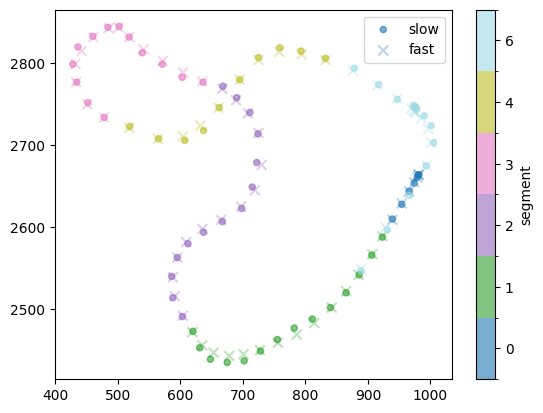

In [12]:
# Extract values from tuples - position_x and position_z contain tuples after matching
x_slow = np.array([val[0] if isinstance(val, tuple) else val for val in df_slow["position_x"]])
z_slow = np.array([val[0] if isinstance(val, tuple) else val for val in df_slow["position_z"]])
x_fast = np.array([val[1] if isinstance(val, tuple) else val for val in df_slow["position_x"]])
z_fast = np.array([val[1] if isinstance(val, tuple) else val for val in df_slow["position_z"]])

seg = df_slow["segment"].to_numpy()

unique = np.unique(seg)
cmap = plt.get_cmap("tab20", len(unique))
norm = BoundaryNorm(np.arange(len(unique)+1) - 0.5, cmap.N)

mapping = {val: i for i, val in enumerate(unique)}
seg_mapped = np.array([mapping[v] for v in seg])

# Plot slow (original) values
sc_slow = plt.scatter(x_slow, z_slow, c=seg_mapped, cmap=cmap, norm=norm, s=20, zorder=5, alpha=0.6, label='slow')
# Plot fast (matched) values in different style
plt.scatter(x_fast, z_fast, c=seg_mapped, cmap=cmap, norm=norm, s=50, zorder=4, alpha=0.3, marker='x', label='fast')

cbar = plt.colorbar(sc_slow, ticks=np.arange(len(unique)))
cbar.ax.set_yticklabels(unique)
cbar.set_label("segment")

plt.legend()
plt.show()

In [13]:
# Write output.txt
records = df_slow.to_dict(orient="records")
text = str(records)
for char in '[]{}()':
    text = text.replace(char, '')
    
text = text.replace('timestamp', '\ntimestamp')

with open(OUTPUT, "w", encoding="utf-8") as f:
    f.write(text)